# Homework 2: SOLUTIONS

### ASTR 324, Spring 2026, Ivezic, University of Washington

https://github.com/uw-astr-324/astr-324-s26



## Problem 1

We learned this week that the posterior pdf for $b$, the tail probability when
flipping a coin, with a flat prior in the range 0-1, is
$$ p(b \,|\, k, N ) = C \, b^k \, (1-b)^{N-k}, $$
where the normalization constant $C$ can be determined from the condition $\int_0^1 p(b\,|\,k,N)\, db = 1$.

Get a REAL coin, flip it 10 times and record your results.

a) plot $p(b \,|\, k, N )$ after each flip. Every time show the previous (prior) $p(b)$
and the posterior $p(b)$. 

b) After all 10 flips, what is the probability that your coin strongly prefers
heads or tails: what is the probability ($p(b<0.45\,|\, k, N )$) OR $p(b>0.55\,|\, k, N )$)) ? 



## Problem 2

Now simulate a coin with $b_\ast = 0.4$. Using code provided in lecture (Week 4), draw a sample of 800 flips. 
Show (plot!) the evolution of $p(b \,|\, k, N )$ after each 100 flips. Alternatively, you can make an animated
gif file (google it!) with all 800 steps (say, 0.05 sec per frame for a 40 sec video clip). 
If we define a "fair" coin as $0.49 < b < 0.51$, what is the probability that this coin is NOT fair given this dataset of 800 flips? 


## Problem 3
Fit polynomials of up to the 10th order to the provided dataset (see below). Show the plot using the code from class as a template. Use BIC to find the best model for this dataset. Is it decisively better than the 2nd best model? 
What about the 3rd best model? What are the values of $\chi^2$ per degree of freedom for the 3 best models?
What do you conclude about selection of the best-fit model in this case? 


## Problem 4

I measured the size of a killer asteroid 3 times and obtained 90, 100, and 120 meters. What is the probability
that this asteroid is larger than 140 meters? What is the result when you naively use Gaussian distribution instead of Student's t distribution? Plot both distributions. Would you bet 1 to 20 that this asteroid is smaller than 140 meters, which is (somewhat artificial) limit for extremely deadly impactors? 

## Problem 5

These questions are similar to those that you will be asked on the final exam. Please answer each one with 1-3 sentences. 

* State what is the probability of model $M$ given some dataset $D$, using Bayes' Theorem: $p(M|D) =....$

* State Bayes' Theorem by explicitly mentioning the vector of model parameters $\theta$ and prior information $I$: 
$p(M, \theta|D,I) =....$

* What does prior probability distribution in Bayesian statistics describe?  

* What is posterior probability distribution in Bayesian statistics describe? 

* We can expand prior probability distribution $p(M, \theta|I) = XXX \,\, p(M|I)$. What is $XXX$ here? 

* If prior probability distribution is described by a wide gaussian and the data likelihood is 
described by a narrow(er) gaussian, how does the posterior probability distribution look like (comment on its location and width relative to locations and widths of prior and likelihood)? 


* When we have no information about prior probability distributions, what should we adopt for priors in case of location and scale parameters? 


* What are nuisance parameters in Bayesian statistics? 

* What is marginalization in Bayesian statistics? 

* You are given posterior probability distribution as a function of k model parameters. What will derivatives of this distribution with respect to each model parameter give you? 

* You are given posterior probability distribution as a function of k model parameters. What will the intergral of this function over all model parameters give you? 

* State the Bayesian Information Criterion and explain what it is good for. 


# Homework 2: Solutions

### Some useful definitions and functions

In [1]:
import numpy as np 
from matplotlib import pyplot as plt
from scipy.stats import norm
np.random.seed(42)

Write your solutions below...

## Problem 1

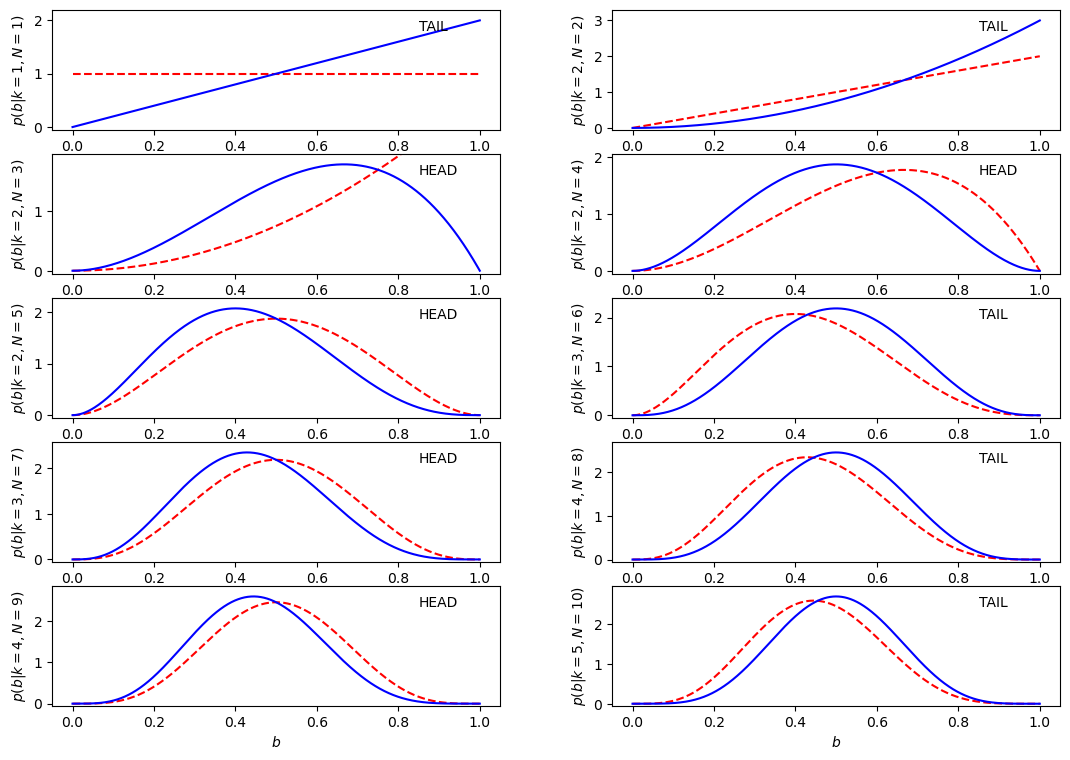

p(b<0.45) OR p(b>0.55):  0.7337569974040594


In [2]:
# results for my coin (0:head, 1: tail)
flipData = [1, 1, 0, 0, 0, 1, 0, 1, 0, 1] 

# plotting setup 
fig = plt.figure(figsize=(12, 12))
fig.subplots_adjust(left=0.11, right=0.95, wspace=0.25, bottom=0.18)
 
# b grid for computing p(b) 
b = np.linspace(0,1,1000)
db = b[1]-b[0]
# prior 
prior_b = 1.0 + 0*b   # flat prior
# prior_b = norm(0.5, 0.1).pdf(b)   Gaussian prior

# loop over data
p_b = prior_b
for i in range(1,11):
    ax = fig.add_subplot(6, 2, i)
    # show p_b before this data point is added
    ax.plot(b, p_b, '--r')
    # now get new p_b
    N = i 
    k = flipData[0:i].count(1)
    # direct formula for p(N,k)
    p_b = prior_b * (b ** k * (1 - b) ** (N - k))
    p_b /= p_b.sum()
    p_b /= db
    # p_b after this data point is added
    label=' z'
    ax.plot(b, p_b, '-b', label=label)
    ax.set_xlabel('$b$')
    s = '$p(b|k=%i' % k
    s = s + ', N=%i)$' % N
    if (flipData[i-1] == 0): 
        ax.text(0.85, np.max(p_b)*0.9,'HEAD')
    else:
        ax.text(0.85, np.max(p_b)*0.9,'TAIL')
    ax.set_ylabel(s)
    ax.set_ylim(-0.05, np.max(p_b)*1.1)
    
plt.show()

cuml_p_b = p_b.cumsum()
cuml_p_b /= cuml_p_b[-1]
pLow = np.interp(0.45, b, cuml_p_b)
pHigh = 1.0 - np.interp(0.55, b, cuml_p_b)
print('p(b<0.45) OR p(b>0.55): ', pLow+pHigh) 

## Problem 2

Now simulate a coin with $b_\ast = 0.4$. Using code provided in lecture (Week 4), draw a sample of 800 flips. 
Show (plot!) the evolution of $p(b \,|\, k, N )$ after each 100 flips. Alternatively, you can make an animated
gif file (google it!) with all 800 steps (say, 0.05 sec per frame for a 40 sec video clip). 
If we define a "fair" coin as $0.49 < b < 0.51$, what is the probability that this coin is NOT fair given this dataset of 800 flips? 

In [3]:
# helper function to make the following code cleaner 
# given coin flip dat and prior p_b, plot the evolution of p_b and return p_b
def plotProblem2(flipData, b, prior_b, plot=False):
    
    # plotting setup 
    if plot:
        fig = plt.figure(figsize=(12, 12))
        fig.subplots_adjust(left=0.11, right=0.95, wspace=0.3, bottom=0.18)
 
    NplotStep = int(np.size(flipData)/8)
    
    # loop over data
    p_b = prior_b
    for i in range(0, np.size(flipData)):
        # get new p_b: posterior = likelihood * prior 
        # note that for problem #1 we used direct formula for (N,k)
        k = flipData[i] 
        p_b = p_b * (b ** k * (1 - b) ** (1 - k))        
        p_b /= p_b.sum()
        p_b /= db
        if plot:
            # plot p_b at this point 
            j = i+1
            if j/NplotStep==int(j/NplotStep): 
                ax = fig.add_subplot(int('52' + str(int(j/NplotStep))))
                ax.plot(b, p_b, '-b')
                ax.set_xlabel('$b$')
                s = 'N=%i' % j
                ax.set_ylabel(s)
                ax.set_ylim(-0.05, np.max(p_b)*1.1)
                ax.set_xlim(0, 1)
                ax.plot([0.49, 0.49], [0, 1000], '-r')
                ax.plot([0.51, 0.51], [0, 1000], '-r')
    if plot:     
        plt.show()

    return p_b

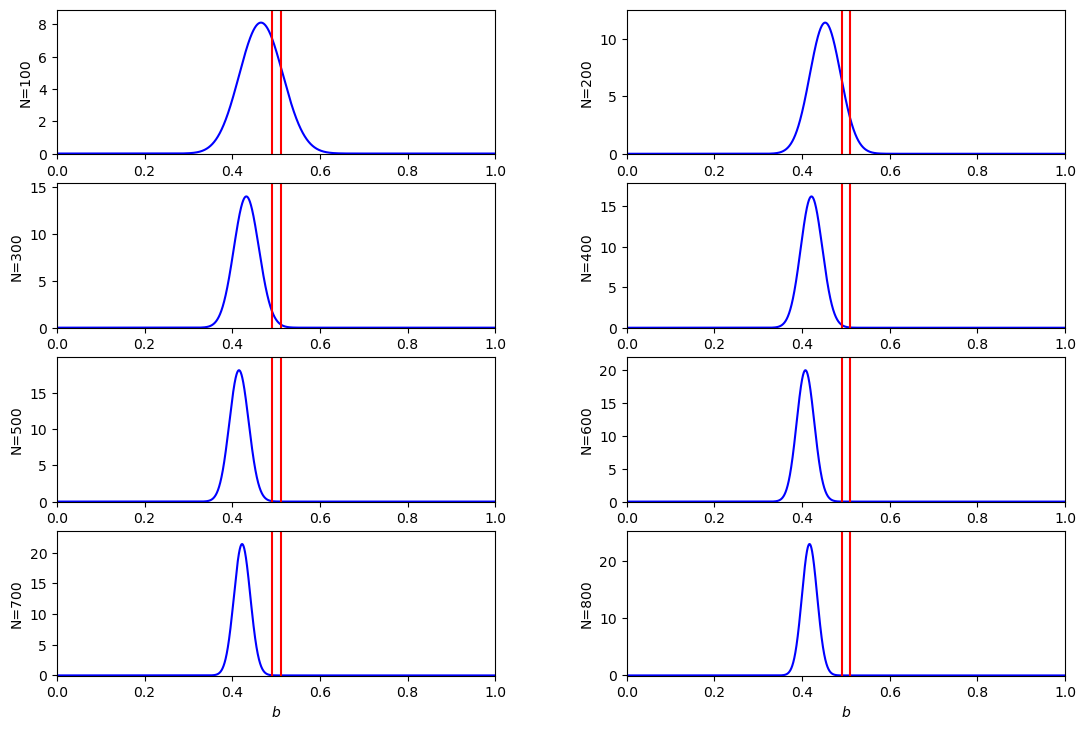

p unfair coint: p(b<0.49) OR p(b>0.51):  0.9999830330674612


In [4]:
# first generate 800 flips
pHead = 0.4
Nflips = 800
np.random.seed(42)
p = np.random.random(Nflips)
flipData = []
for i in range(0,Nflips):
    if p[i] < pHead:
        flipData.append(1)
    else:
        flipData.append(0)

# generate b grid for posterior pdf
b = np.linspace(0, 1, 10000)
db = b[1] - b[0]

# generate prior pdf
p_b = 1*b
p_b /= p_b.sum()
p_b /= db

# evaluate posterior p_b and plot p_b evolution
p_b = plotProblem2(flipData, b, p_b, plot=True) 

# evaluate probability of unfair coin
cuml_p_b = p_b.cumsum()
cuml_p_b /= cuml_p_b[-1]  
pUnfair = np.interp(0.49, b, cuml_p_b) + (1-np.interp(0.51, b, cuml_p_b))
print('p unfair coint: p(b<0.49) OR p(b>0.51): ', pUnfair)   

## Problem 3

In [5]:
# generate (noisy) data
np.random.seed(42)
Ndata = 20
x = np.linspace(0, 5, Ndata)
sigma_y = 0.1 + 0*x + np.random.normal(0*x, 0.02) 
y = np.random.normal(np.cos(x) * x, sigma_y) 

### this is the provided dataset to fit:

In [6]:
x = np.array([0.0, 0.26315789, 0.52631579, 0.78947368, 1.05263158, 1.31578947, 1.57894737, 1.84210526, 2.10526316, 2.36842105, 2.63157895, 2.89473684, 3.15789474, 3.42105263, 3.68421053, 3.94736842, 4.21052632, 4.47368421, 4.73684211, 5.0])
y = np.array([-0.01519999,  0.32530142,  0.62251935,  0.53022095,  0.49561467, 0.50552021,  0.07149746, -0.54528213, -1.01273784, -1.74602254, -2.34787813, -2.78038444, -3.36781022, -3.47795891, -3.21682447, -2.84510209, -1.99096649, -1.1576002 , -0.03944155,  1.57943597])
yErr = np.array([0.10993428, 0.09723471, 0.11295377, 0.1304606 , 0.09531693, 0.09531726, 0.13158426, 0.11534869, 0.09061051, 0.1108512, 0.09073165, 0.0906854 , 0.10483925, 0.0617344 , 0.06550164, 0.08875425, 0.07974338, 0.10628495, 0.08183952, 0.07175393])

In [7]:
from scipy import stats
from scipy import optimize

# this function computes polynomial models given some data x
# and parameters theta
def polynomial_fit(theta, x):
    """Polynomial model of degree (len(theta) - 1)"""
    return sum(t * x ** n for (n, t) in enumerate(theta))

# compute the data log-likelihood given a model
def logL(theta, x, y, sigma_y, model=polynomial_fit):
    """Gaussian log-likelihood of the model at theta"""
    y_fit = model(theta, x)
    return sum(stats.norm.logpdf(*args)
               for args in zip(y, y_fit, sigma_y))

# a direct optimization approach is used to get best model 
# parameters (which minimize -logL)
def best_theta(degree, x, y, sigma_y, model=polynomial_fit):
    theta_0 = (degree + 1) * [0]
    neg_logL = lambda theta: -logL(theta, x, y, sigma_y, model)
    return optimize.fmin_bfgs(neg_logL, theta_0, disp=False)

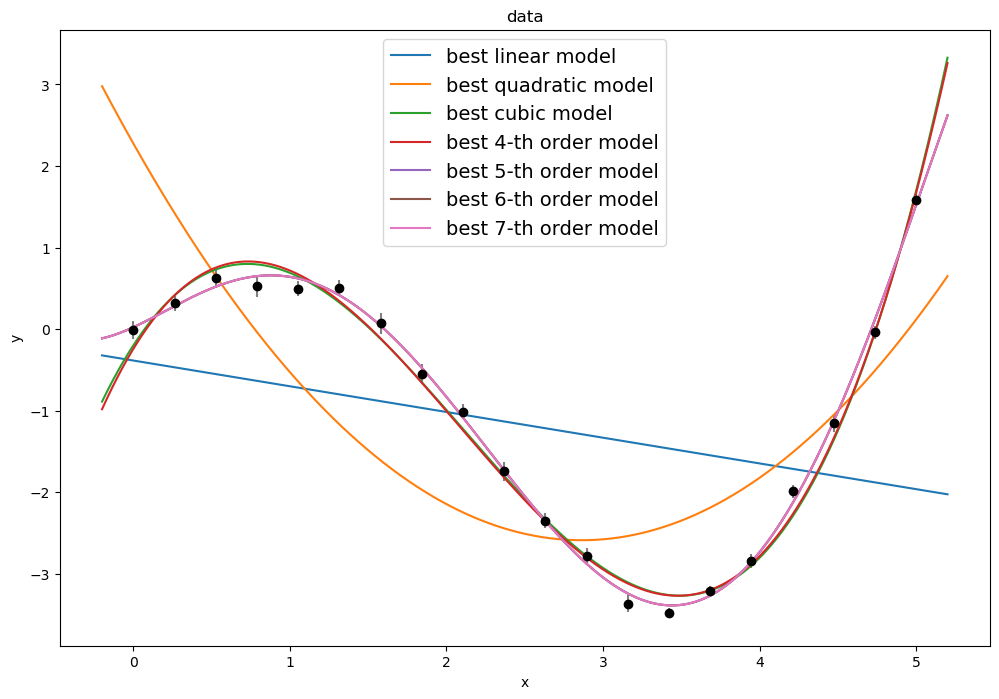

In [8]:
sigma_y = yErr
# get best-fit parameters for linear, quadratic and cubic models
theta1 = best_theta(1, x, y, sigma_y)
theta2 = best_theta(2, x, y, sigma_y)
theta3 = best_theta(3, x, y, sigma_y)
theta4 = best_theta(4, x, y, sigma_y)
theta5 = best_theta(5, x, y, sigma_y)
theta6 = best_theta(6, x, y, sigma_y)
theta7 = best_theta(7, x, y, sigma_y)
theta8 = best_theta(8, x, y, sigma_y)
theta9 = best_theta(9, x, y, sigma_y)
theta10 = best_theta(10, x, y, sigma_y)


# generate best fit lines on a fine grid 
xfit = np.linspace(-0.2, 5.2, 1000)
yfit1 = polynomial_fit(theta1, xfit)
yfit2 = polynomial_fit(theta2, xfit)
yfit3 = polynomial_fit(theta3, xfit)
yfit4 = polynomial_fit(theta4, xfit)
yfit5 = polynomial_fit(theta5, xfit)
yfit6 = polynomial_fit(theta6, xfit)
yfit7 = polynomial_fit(theta7, xfit)
yfit8 = polynomial_fit(theta8, xfit)
yfit9 = polynomial_fit(theta9, xfit)
yfit10 = polynomial_fit(theta10, xfit)


# plot 
fig, ax = plt.subplots(figsize=(12, 8))
ax.errorbar(x, y, sigma_y, fmt='ok', ecolor='gray')
ax.plot(xfit, polynomial_fit(theta1, xfit), label='best linear model')
ax.plot(xfit, polynomial_fit(theta2, xfit), label='best quadratic model')
ax.plot(xfit, polynomial_fit(theta3, xfit), label='best cubic model')
ax.plot(xfit, polynomial_fit(theta4, xfit), label='best 4-th order model')
ax.plot(xfit, polynomial_fit(theta5, xfit), label='best 5-th order model')
ax.plot(xfit, polynomial_fit(theta5, xfit), label='best 6-th order model')
ax.plot(xfit, polynomial_fit(theta5, xfit), label='best 7-th order model')

ax.legend(loc='best', fontsize=14)
ax.set(xlabel='x', ylabel='y', title='data');

In [9]:
theta5

array([ 0.02299728,  0.88370827,  0.72181362, -1.34934527,  0.39291482,
       -0.03131753])

In [10]:
# compute chi2 per degree of freedom: sum{[(y-yfit)/sigma_y]^2} 
chi21 = np.sum(((y-polynomial_fit(theta1, x))/sigma_y)**2)   
chi22 = np.sum(((y-polynomial_fit(theta2, x))/sigma_y)**2)   
chi23 = np.sum(((y-polynomial_fit(theta3, x))/sigma_y)**2)   
chi24 = np.sum(((y-polynomial_fit(theta4, x))/sigma_y)**2)   
chi25 = np.sum(((y-polynomial_fit(theta5, x))/sigma_y)**2)   
chi26 = np.sum(((y-polynomial_fit(theta6, x))/sigma_y)**2)  
chi27 = np.sum(((y-polynomial_fit(theta7, x))/sigma_y)**2)  




# the number of fitted parameters is 2, 3, 4, 5, 6
BIC1 = chi21 + 2*np.log(Ndata)
BIC2 = chi22 + 3*np.log(Ndata)
BIC3 = chi23 + 4*np.log(Ndata)
BIC4 = chi24 + 5*np.log(Ndata)
BIC5 = chi25 + 6*np.log(Ndata)
BIC6 = chi26 + 7*np.log(Ndata)
BIC7 = chi27 + 8*np.log(Ndata)


print ("         MODEL             CHI2          BIC")
print ('    best linear model:', chi21, BIC1)
print (' best quadratic model:', chi22, BIC2)
print ('     best cubic model:', chi23, BIC3)
print ('best 4-th order model:', chi24, BIC4)
print ('best 5-th order model:', chi25, BIC5)
print ('best 6-th order model:', chi26, BIC6)
print ('best 7-th order model:', chi27, BIC7)
 

         MODEL             CHI2          BIC
    best linear model: 6384.903159375277 6390.894623922385
 best quadratic model: 2792.9172325600193 2801.9044293806814
     best cubic model: 63.35225028706158 75.33517938127754
best 4-th order model: 62.43668452490436 77.41534589267431
best 5-th order model: 18.709093243962403 36.68348688528635
best 6-th order model: 19.721117295177677 40.69124321005562
best 7-th order model: 103.06937619303618 127.0352343814681


In [11]:
for chi2, kFitParam in zip([18.70, 19.72, 63.4], [6, 7, 4]):
    kDOF = Ndata - kFitParam
    print(chi2/kDOF)

1.3357142857142856
1.5169230769230768
3.9625


### Use BIC to find the best model for this dataset. Is it decisively better than the 2nd best model? 

The best-fit model is the 5-th order polynomial because its BIC is the lowest (37). However, the second-best
model, the 6-th order polynomial, has BIC = 41, and thus those two models cannot be strongly distinguished from 
each other. 


### What about the 3rd best model? 

The third-best model, the 3-rd order polynomial, has BIC = 75 and thus can be strongly
rejected compared to the first and second best models.


### What are the values of $\chi^2$ per degree of freedom for the 3 best models?

For the 5-th, 6-th and 3-rd order polynomial models, $\chi^2$ per degree of freedom is 1.34, 1.52 and 4.0. 


### What do you conclude about selection of the best-fit model in this case? 

In this case, the second-best model has, in addition to having larger 
penalty for complexity, also larger $\chi^2$ per degree of freedom. Nevertheless, differences are small
and can be attributed to statistical fluctuations. These two models cannot be strongly distinguished from 
each other. 

## Problem 4

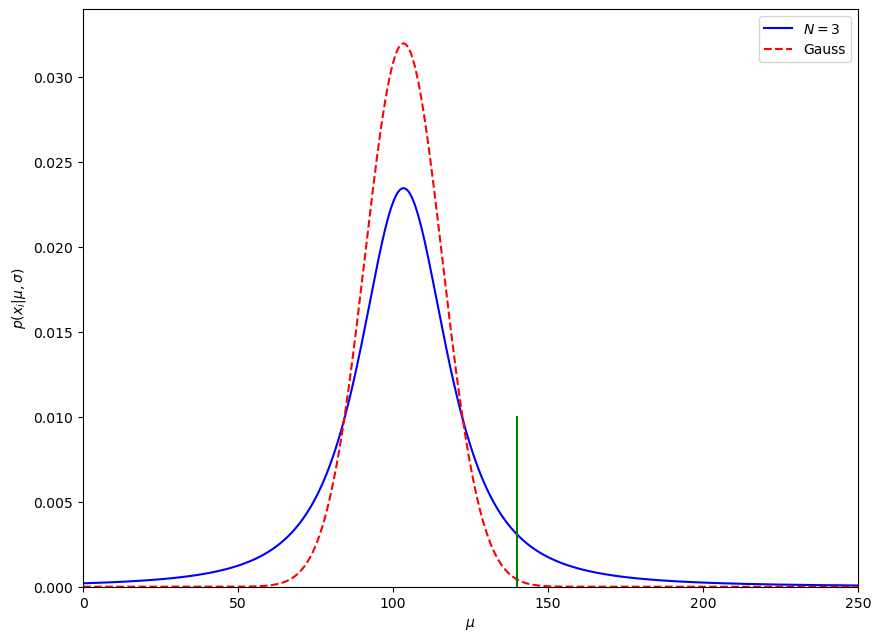

p(>140m) for Student: 0.06685416186821978
p(>140m) for Gauss: 0.001603493935337716
p ratio for Student: 14.957931893173075
p ratio for Gauss: 623.638155381852


In [12]:
# data
x = np.array([90, 100, 120])
Ndata = 3
xbar = np.sum(x)/Ndata
V = np.sum((x-xbar)**2)

 
# p(mu) from Student's t distribution
def compute_pmu(mu, xbar, V, N):
    p = (1 + (xbar - mu) ** 2 / V) ** (-0.5 * N)
    return p / (mu[1]-mu[0]) / np.sum(p)

# posteriors (assuming flat priors)
mu = np.linspace(0, 300, 1000)
pmu = compute_pmu(mu,xbar,V,Ndata)
G = norm(xbar, np.sqrt(V/Ndata)).pdf(mu) 
Gnorm = G / (mu[1]-mu[0]) / np.sum(G)
 
## plot
fig, ax = plt.subplots(figsize=(10, 7.5))
plt.plot(mu, pmu, ls='-', c='blue', label=r'$N=3$')
plt.plot(mu, Gnorm, ls='--', c='red', label=r'Gauss')
plt.plot([140, 140], [0, 0.01], c='green')

plt.xlim(0, 250)
plt.ylim(0, 0.034)
plt.xlabel('$\mu$')
plt.ylabel(r'$p(x_i|\mu,\sigma)$')
plt.legend()
plt.show() 

# the tail area
def computeTailArea(x, f, xMin):
    fTail = f[x>=xMin]
    return(np.sum(fTail)*(x[1]-x[0]))

pMU = computeTailArea(mu, pmu, 140)
pMUgauss = computeTailArea(mu, Gnorm, 140)
print('p(>140m) for Student:', pMU)
print('p(>140m) for Gauss:', pMUgauss)
betRatio = 1/pMU
betRatioG = 1/pMUgauss
print('p ratio for Student:', betRatio)
print('p ratio for Gauss:', betRatioG)

### Would you bet 1 to 20 that this asteroid is smaller than 140 meters, which is (somewhat artificial) limit for extremely deadly impactors? 

Betting "1 to 20 (or 1:20)" means that you bet $\$ 20$ in order to win $ \$ 1$ (and get back your $\$ 20$). 
If you are certain something will happen (i.e. with probability=1), it's a good bet! It's a tie when the probability is 20/21 = 95.2\%. 

So, this question is essentially asking "Is the probability that this asteroid is smaller than 140 meters at least as high as 95.2\% ($p \ge 0.952$). 


The correct Student distribution shows that betting that this asteroid is smaller than 140 meters would have a winning probability of 1:15. Therefore, betting 1:20 is a losing proposal. Note, however, that using Gaussian distribution, with a winning probability of 1:624, would **mislead** you to think that a 1:20 bet is a great proposition. 

Note that a similar question would be "Would you bet **20 to 1** that this asteroid is **larger** than 140 meters?

## Problem 5


* State what is the probability of model $M$ given some dataset $D$, using Bayes' Theorem: 

    $$p(M|D) =  \frac{p(D\,|\,M)\,p(M)}{p(D)}$$

* State Bayes' Theorem by explicitly mentioning the vector of model parameters $\theta$ and prior information $I$: 

    $$p(M, \theta|D,I) =\frac{p(D\,|\,M,\theta,I)\,p(M,\theta\,|\,I)}{p(D\,|\,I)} $$

* What does prior probability distribution in Bayesian statistics describe?  

It describes the state of our knowledge (based on old, prior, measurements or other information) 
before any data (new measurements) are taken into account.

* What does posterior probability distribution in Bayesian statistics describe? 

It describes the state of our knowledge after new data (new measurements) are taken into account.


* We can expand prior probability distribution $p(M, \theta|I) = XXX \,\, p(M|I)$. What is $XXX$ here? 

$$p(M, \theta|I) = p(\theta\,|\,M,I)\,p(M\,|\,I) $$

* If prior probability distribution is described by a wide gaussian and the data likelihood is 
described by a narrow(er) gaussian, how does the posterior probability distribution look like (comment on its location and width relative to locations and widths of prior and likelihood)? 

The posterior is narrower than either prior of likelihood and centered on a location that is closer
to the likelihood peak. In the limit of prior being so wide that it looks flat compared to likelihood,
the posterior looks like likelihood (with its integral normalized to unity). 


* When we have no information about prior probability distributions, what should we adopt for priors in case of location and scale parameters? 

For location we should adopt uniform (flat) prior and for scale parameter Jeffrey's prior (flat in log space):
$p(\theta|I) \propto 1/\theta$.


* What are nuisance parameters in Bayesian statistics? 

Parameters that are required to model prior or likelihood, but whose posteriors are not of interest. 

* What is marginalization in Bayesian statistics? 

Marginalization is integration over a subset of parameters that posterior depends on (e.g. over nuisance parameters). 

* You are given posterior probability distribution as a function of k model parameters. What will derivatives of this distribution with respect to each model parameter give you? 

They will give us most likely parameter values. 

* You are given posterior probability distribution as a function of k model parameters. What will the intergral of this function over all model parameters give you? 

It will give us posterior model probability. 

* State the Bayesian Information Criterion and explain what it is good for. 

    $$ {\rm BIC} = \chi^2 + k \ln N $$ 

BIC measures the model success in fitting data through $ \chi^2 $ while penalizing models for their complexity (the number of parameters) via the second term. BIC is an asymptotic approximation for the posterior model probability and can be used to choose the most probable models out of a set of all models. 